#Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from google.colab import drive

!pip install bertopic
from bertopic import BERTopic

# Embedding -> Dim. Red. -> Clustering


**Dataset loading and filtering**

In [ ]:
#Prendiamo le prime 50k istanze
dataset = pd.DataFrame(load_dataset("pubmed_qa", "pqa_artificial", split="train"))[:50000]

In [ ]:
#vogliamo lavorare solamente con question e long_answ
questions = dataset["question"]
contexts = dataset["long_answer"]
del dataset

In [ ]:
# display(contexts.head())
# display(questions.head())

In [ ]:
questions.isna().sum()

np.int64(0)

In [ ]:
contexts.isna().sum()

np.int64(0)

**Embeddings creation**

In [ ]:
model = SentenceTransformer("thenlper/gte-small")
embeddings = model.encode(contexts)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: thenlper/gte-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


**Embeddings dimensionality reduction**

In [ ]:
umap_model = UMAP(n_components = 2, min_dist = 0.0, metric = "cosine", random_state = 42)
reduced_embeddings = umap_model.fit_transform(embeddings)

**HDBSCAN clustering**

In [ ]:
#sometimes returns 3 clusters, don't know why...
hdbscan_model = HDBSCAN(min_cluster_size=40, metric = "euclidean", cluster_selection_method = "eom").fit(reduced_embeddings)
#Getting clusters labels
clusters = hdbscan_model.labels_
#Seeing how many clusters
len(set(clusters))

118

**Clusters visualization**

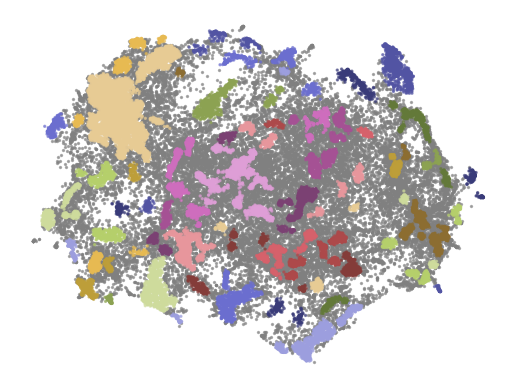

In [ ]:
df = pd.DataFrame(reduced_embeddings, columns=["x", "y"])
df["long_answer"] = contexts[:len(df)]
df["cluster"] = clusters

#Not outliers
to_plot_df = df.loc[df.cluster != -1]
#Outliers
outliers_df = df.loc[df.cluster == -1]
#Outliers scatterplot
plt.scatter(outliers_df.x, outliers_df.y, alpha=0.6, s=2, c="grey")
#Clusters scatterplot
plt.scatter(to_plot_df.x, to_plot_df.y, c=to_plot_df.cluster.astype(int),alpha=0.6, s=2, cmap="tab20b")
plt.axis("off")
del to_plot_df, outliers_df

**3D visualization**

In [ ]:
umap_model_3d = UMAP(n_components = 3, min_dist = 0.0, metric = "cosine", random_state = 42)
reduced_embeddings_3d = umap_model_3d.fit_transform(embeddings)

In [ ]:
#sometimes returns 3 clusters, don't know why...
hdbscan_model_3d = HDBSCAN(min_cluster_size=40, metric = "euclidean", cluster_selection_method = "eom").fit(reduced_embeddings_3d)
#Getting clusters labels
clusters_3d = hdbscan_model_3d.labels_
#Seeing how many clusters
len(set(clusters_3d))

108

In [ ]:
df_3d = pd.DataFrame(reduced_embeddings_3d, columns=["x", "y", "z"])
df_3d["long_answer"] = contexts[:len(df)]
df_3d["cluster"] = clusters_3d

#Not outliers
to_plot_df_3d = df_3d.loc[df_3d.cluster != -1]
#Outliers
outliers_df_3d = df_3d.loc[df_3d.cluster == -1]

fig = go.Figure()

# to_plot_df (colored by cluster)
fig.add_trace(
    go.Scatter3d(
        x=to_plot_df_3d.x,
        y=to_plot_df_3d.y,
        z=to_plot_df_3d.z,
        mode="markers",
        marker=dict(
            size=3,
            color=to_plot_df_3d.cluster,
            colorscale="Turbo",
            opacity=1
        ),
        name="Clusters",
        #hovertext=to_plot_df.long_answer,
        hovertext=None,
        hoverinfo="text"
    )
)

# Outliers (grey)
fig.add_trace(
    go.Scatter3d(
        x=outliers_df_3d.x,
        y=outliers_df_3d.y,
        z=outliers_df_3d.z,
        mode="markers",
        marker=dict(
            size=2,
            color="grey",
            opacity=0.2
        ),
        name="Outliers",
        #hovertext=to_plot_df.long_answer,
        hovertext=None,
        hoverinfo="text"
    )
)

fig.update_layout(
    height=800,
    scene=dict(
        xaxis_title="x",
        yaxis_title="y",
        zaxis_title="z"
    )
)

fig.show()
del df_3d, to_plot_df_3d, outliers_df_3d, df

**Checking the cluster=0 contexts**

In [ ]:
pd.set_option('display.max_colwidth', 150)
cluster = 0
index = np.where(clusters==cluster)
contexts.iloc[index][:10]

,long_answer
226,Our study is based on self-reported migraine.
370,"We investigated cortical excitability in episodic cluster headache by using transcranial magnetic stimulation, providing evidence of cortical hype..."
519,"Gender has an influence on the characteristics of the headache as well as on the associated symptoms in migraine patients, and this impact varies ..."
2185,"This study identified allodynia, in addition to high migraine attack frequency, as a new migraine-specific factor associated with depression."
3104,Interictal migraineurs and controls performance is identical in a brief cognitive battery focused on executive functions. Repeated applications pr...
4474,Children with migraine with aura have a substantial increased risk to develop subsequent epilepsy. This finding is consistent with the hypothesis ...
4877,This study showed an increased risk of developing PD in patients with migraine.
4996,"There is a paucity of studies in quality of life, productivity, and psychosocial aspects with peripheral nerve stimulation therapy for headache. P..."
5712,This meta-analysis demonstrates that subjects with migraine are at higher risk of having WMAs on magnetic resonance images than those without migr...
6990,"RTMS reduced habituation only in migraineurs, indicating increased responsivity to rTMS. The magnocellular visual subsystem may be affected interi..."


# Topic Modeling

In [ ]:
topic_model = BERTopic(
                        embedding_model = model,
                        umap_model = umap_model,
                        hdbscan_model = hdbscan_model,
                        verbose=True).fit(contexts, embeddings)

2026-02-18 20:34:42,296 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-02-18 20:35:28,193 - BERTopic - Dimensionality - Completed ✓
2026-02-18 20:35:28,194 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-02-18 20:35:29,597 - BERTopic - Cluster - Completed ✓
2026-02-18 20:35:29,610 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-02-18 20:35:31,145 - BERTopic - Representation - Completed ✓


In [ ]:
#Setting the DataFrame max column width back to standard values
pd.set_option('display.max_colwidth', 50)

In [ ]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,22961,-1_of_the_in_and,"[of, the, in, and, to, with, that, is, for, be]",[Clinical signs of pulmonary congestion indica...
1,0,4005,0_cancer_tumor_cells_expression,"[cancer, tumor, cells, expression, cell, breas...",[IL-6 was significantly associated with poor p...
2,1,1066,1_asthma_allergic_airway_ige,"[asthma, allergic, airway, ige, allergen, il, ...",[Omalizumab exerts inhibitory effects on airwa...
3,2,987,2_pain_propofol_morphine_isoflurane,"[pain, propofol, morphine, isoflurane, anesthe...",[The analgesic interaction between intrathecal...
4,3,833,3_mutation_gene_mutations_genetic,"[mutation, gene, mutations, genetic, polymorph...",[Our results suggest that genetic variation at...
...,...,...,...,...,...
113,112,43,112_anastomotic_leakage_anastomosis_trpa1,"[anastomotic, leakage, anastomosis, trpa1, pos...","[Anastomotic sealing using TissuCol(®), Histoa..."
114,113,43,113_resection_melanoma_hepatectomy_liver,"[resection, melanoma, hepatectomy, liver, hepa...",[Major hepatic resection is more effective in ...
115,114,41,114_alerts_dnr_cdss_ed,"[alerts, dnr, cdss, ed, nurses, edwin, informa...",[Using clusters of drug interaction alerts wit...
116,115,41,115_aki_fluid_catecholamine_septic,"[aki, fluid, catecholamine, septic, mortality,...",[Fluid resuscitation results in positive fluid...


In [ ]:
indexes,values = topic_model.find_topics("vision")
indexes,values

([6, 70, 84, -1, 18],
 [np.float64(0.8776600012469553),
  np.float64(0.8600458674900362),
  np.float64(0.8566932026275937),
  np.float64(0.8553314847012494),
  np.float64(0.8527980180138812)])

In [ ]:
#printing the representations for each index found
for index in indexes:
  for topic in topic_model.get_topic(index):
    #print(topic)
    print(topic[0])
  print("------------------------------------------")
  #print(topic_model.get_topic(index))

retinal
corneal
retina
lens
eyes
eye
glaucoma
ocular
visual
the
------------------------------------------
motor
cortical
visual
excitability
corticospinal
vestibular
movements
eye
tdcs
sensorimotor
------------------------------------------
trauma
injuries
injured
mri
imaging
injury
ct
centers
patient
head
------------------------------------------
of
the
in
and
to
with
that
is
for
be
------------------------------------------
care
research
sample
to
health
meta
trials
reviews
retrospective
physician
------------------------------------------


**Visualization**

In [ ]:
fig = topic_model.visualize_documents(
                                      questions,
                                      reduced_embeddings = reduced_embeddings,
                                      width = 1200,
                                      hide_annotations = True)
fig.update_layout(font = dict(size = 16))
topic_model.visualize_barchart()

In [ ]:
topic_model.visualize_barchart()
topic_model.visualize_hierarchy()
topic_model.visualize_heatmap(n_clusters=10)

## Generate topic csv for lab. 5

In [ ]:
df = topic_model.get_topic_info()

drive.mount('/content/drive', force_remount = True)
df.to_csv("/content/drive/MyDrive/Progetti_TLN/Progetto_Di_Caro/Nostri_progetti/5/topic_lab_4.csv", index = False)

Mounted at /content/drive
